In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('customer_value_clean.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (3900, 28)
Columns: ['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases', 'Frequency_Score', 'Promo_Dependency_Score', 'Amount_Normalized', 'Frequency_Normalized', 'Value_Score', 'Value_Tier', 'Loyalty_Def1', 'Loyalty_Def2', 'Satisfaction_Flag', 'Age_Group']


In [2]:
# Which states have the most customers and highest revenue?
geo = df.groupby('Location').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Purchase_Amount_USD', 'sum'),
    Avg_Spend=('Purchase_Amount_USD', 'mean'),
    Avg_Promo_Dependency=('Promo_Dependency_Score', 'mean'),
    Loyalty_Rate=('Loyalty_Def1', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print('Top 15 States by Revenue:')
print(geo.head(15))

Top 15 States by Revenue:
               Customer_Count  Total_Revenue  Avg_Spend  Avg_Promo_Dependency  \
Location                                                                        
Montana                    96           5784      60.25                  0.38   
Illinois                   92           5617      61.05                  0.40   
California                 95           5605      59.00                  0.42   
Idaho                      93           5587      60.08                  0.41   
Nevada                     87           5514      63.38                  0.47   
Alabama                    89           5261      59.11                  0.40   
New York                   87           5257      60.43                  0.41   
North Dakota               83           5220      62.89                  0.46   
West Virginia              81           5174      63.88                  0.49   
Nebraska                   87           5172      59.45                  0.43   
Ne

In [3]:
# Which states buy organically vs discount-driven?
# High spend + low promo dependency = genuine brand pull
geo['Organic_Opportunity'] = (
    (geo['Avg_Spend'] >= geo['Avg_Spend'].median()) &
    (geo['Avg_Promo_Dependency'] <= geo['Avg_Promo_Dependency'].median())
)

print('States with HIGH spend and LOW promo dependency (Organic Markets):')
print(geo[geo['Organic_Opportunity'] == True][['Customer_Count', 'Avg_Spend', 'Avg_Promo_Dependency']].sort_values('Avg_Spend', ascending=False))

States with HIGH spend and LOW promo dependency (Organic Markets):
              Customer_Count  Avg_Spend  Avg_Promo_Dependency
Location                                                     
Alaska                    72      67.60                  0.40
Arizona                   65      66.55                  0.34
Virginia                  77      62.88                  0.38
Michigan                  73      62.10                  0.40
Tennessee                 77      61.97                  0.36
Rhode Island              63      61.44                  0.40
Texas                     77      61.19                  0.36
Illinois                  92      61.05                  0.40
Wyoming                   71      60.69                  0.42
South Dakota              70      60.51                  0.37
New York                  87      60.43                  0.41
Montana                   96      60.25                  0.38


In [4]:
seasonal = df.groupby('Season').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Purchase_Amount_USD', 'sum'),
    Avg_Spend=('Purchase_Amount_USD', 'mean'),
    Promo_Dependency=('Promo_Dependency_Score', 'mean'),
    Loyalty_Rate=('Loyalty_Def1', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print('Revenue and Loyalty by Season:')
print(seasonal)

Revenue and Loyalty by Season:
        Customer_Count  Total_Revenue  Avg_Spend  Promo_Dependency  \
Season                                                               
Fall               975          60018      61.56              0.41   
Spring             999          58679      58.74              0.44   
Winter             971          58607      60.36              0.43   
Summer             955          55777      58.41              0.44   

        Loyalty_Rate  
Season                
Fall            0.15  
Spring          0.15  
Winter          0.17  
Summer          0.17  


In [5]:
category = df.groupby('Category').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Purchase_Amount_USD', 'sum'),
    Avg_Spend=('Purchase_Amount_USD', 'mean'),
    Promo_Dependency=('Promo_Dependency_Score', 'mean'),
    Loyalty_Rate=('Loyalty_Def1', 'mean'),
    Avg_Previous_Purchases=('Previous_Purchases', 'mean'),
    Satisfaction=('Satisfaction_Flag', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print('Category Analysis:')
print(category)

Category Analysis:
             Customer_Count  Total_Revenue  Avg_Spend  Promo_Dependency  \
Category                                                                  
Clothing               1737         104264      60.03              0.42   
Accessories            1240          74200      59.84              0.44   
Footwear                599          36093      60.26              0.43   
Outerwear               324          18524      57.17              0.44   

             Loyalty_Rate  Avg_Previous_Purchases  Satisfaction  
Category                                                         
Clothing             0.17                   25.20          0.40  
Accessories          0.15                   25.73          0.43  
Footwear             0.16                   25.23          0.45  
Outerwear            0.15                   24.96          0.43  


In [6]:
payment = df.groupby('Payment_Method').agg(
    Customer_Count=('Customer_ID', 'count'),
    Avg_Spend=('Purchase_Amount_USD', 'mean'),
    Promo_Dependency=('Promo_Dependency_Score', 'mean'),
    Loyalty_Rate=('Loyalty_Def1', 'mean')
).round(2).sort_values('Avg_Spend', ascending=False)

print('Payment Method Analysis:')
print(payment)

Payment Method Analysis:
                Customer_Count  Avg_Spend  Promo_Dependency  Loyalty_Rate
Payment_Method                                                           
Debit Card                 636      60.92              0.45          0.15
Credit Card                671      60.07              0.42          0.19
Bank Transfer              612      59.71              0.42          0.16
Cash                       670      59.70              0.42          0.16
PayPal                     677      59.25              0.41          0.17
Venmo                      634      58.95              0.45          0.15


In [10]:
profile = df.groupby('Loyalty_Def1').agg(
    Count=('Customer_ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Spend=('Purchase_Amount_USD', 'mean'),
    Avg_Previous_Purchases=('Previous_Purchases', 'mean'),
    Promo_Dependency=('Promo_Dependency_Score', 'mean'),
    Satisfaction=('Review_Rating', 'mean'),
    Subscription_Rate=('Subscription_Status', 'mean')
).round(2)

profile.index = ['Non-Loyal', 'Loyal']
print('Loyal vs Non-Loyal Customer Profile:')
print(profile)

Loyal vs Non-Loyal Customer Profile:
           Count  Avg_Age  Avg_Spend  Avg_Previous_Purchases  \
Non-Loyal   3273    43.90      59.58                   23.11   
Loyal        627    44.96      60.72                   37.05   

           Promo_Dependency  Satisfaction  Subscription_Rate  
Non-Loyal              0.51          3.74               0.32  
Loyal                  0.00          3.79               0.00  


In [11]:
age_cat = df.groupby(['Age_Group', 'Category'])['Purchase_Amount_USD'].sum().reset_index()
top_cat = age_cat.loc[age_cat.groupby('Age_Group')['Purchase_Amount_USD'].idxmax()]
top_cat.columns = ['Age_Group', 'Top_Category', 'Revenue']
print('Most Popular Category by Age Group:')
print(top_cat.to_string(index=False))

Most Popular Category by Age Group:
             Age_Group Top_Category  Revenue
          Boomer (55+)     Clothing    31504
         Gen X (45-54)     Clothing    19612
         Gen Z (18-24)     Clothing    14050
Mid-Millennial (35-44)     Clothing    18630
    Millennial (25-34)     Clothing    20468


In [12]:
loyal_promo = df[df['Loyalty_Def1']==1]['Promo_Dependency_Score'].value_counts()
nonloyal_promo = df[df['Loyalty_Def1']==0]['Promo_Dependency_Score'].value_counts()

print('Promo usage among LOYAL customers:')
print(loyal_promo)
print(f'\nPromo usage among NON-LOYAL customers:')
print(nonloyal_promo)

Promo usage among LOYAL customers:
Promo_Dependency_Score
0.00    627
Name: count, dtype: int64

Promo usage among NON-LOYAL customers:
Promo_Dependency_Score
1.00    1677
0.00    1596
Name: count, dtype: int64


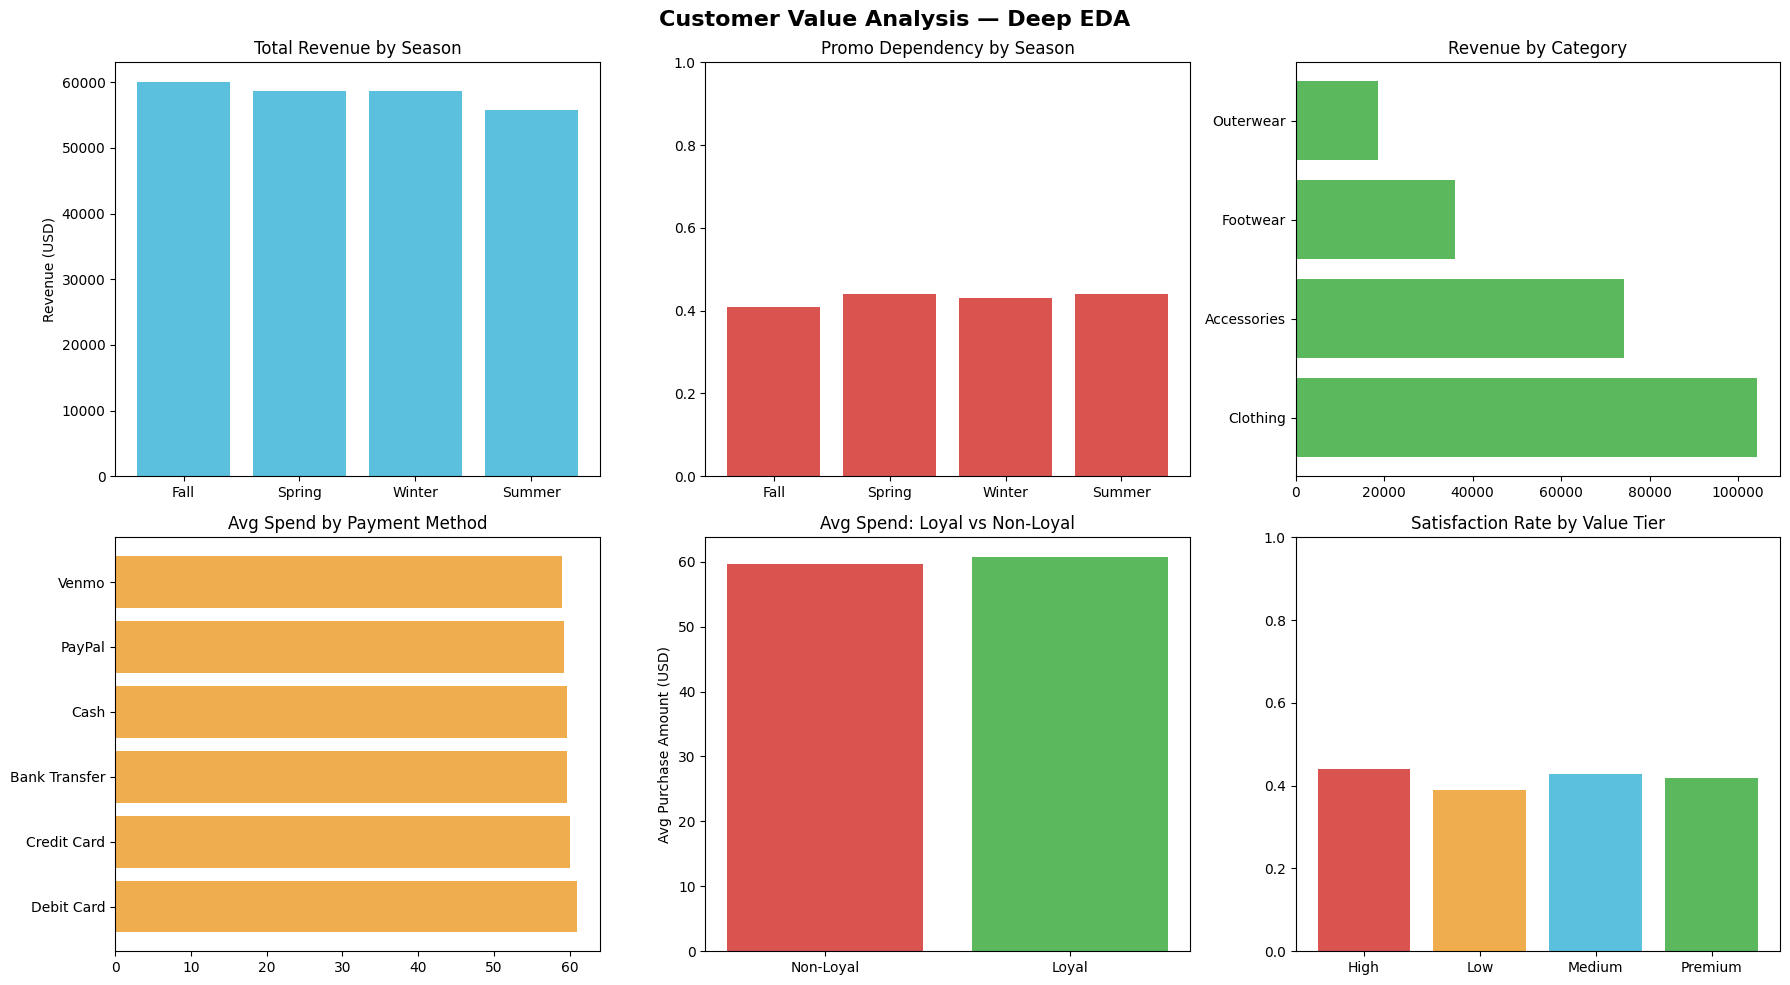

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Value Analysis — Deep EDA', fontsize=16, fontweight='bold')

# Plot 1: Revenue by Season
axes[0,0].bar(seasonal.index, seasonal['Total_Revenue'], color='#5bc0de')
axes[0,0].set_title('Total Revenue by Season')
axes[0,0].set_ylabel('Revenue (USD)')

# Plot 2: Promo Dependency by Season
axes[0,1].bar(seasonal.index, seasonal['Promo_Dependency'], color='#d9534f')
axes[0,1].set_title('Promo Dependency by Season')
axes[0,1].set_ylim(0, 1)

# Plot 3: Category Revenue
axes[0,2].barh(category.index, category['Total_Revenue'], color='#5cb85c')
axes[0,2].set_title('Revenue by Category')

# Plot 4: Payment Method vs Avg Spend
axes[1,0].barh(payment.index, payment['Avg_Spend'], color='#f0ad4e')
axes[1,0].set_title('Avg Spend by Payment Method')

# Plot 5: Loyal vs Non-Loyal Avg Spend
axes[1,1].bar(['Non-Loyal', 'Loyal'], profile['Avg_Spend'], color=['#d9534f', '#5cb85c'])
axes[1,1].set_title('Avg Spend: Loyal vs Non-Loyal')
axes[1,1].set_ylabel('Avg Purchase Amount (USD)')

# Plot 6: Satisfaction by Value Tier
tier_sat = df.groupby('Value_Tier', observed=True)['Satisfaction_Flag'].mean()
axes[1,2].bar(tier_sat.index, tier_sat.values, color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'])
axes[1,2].set_title('Satisfaction Rate by Value Tier')
axes[1,2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
geo.head(15).to_csv('geo_analysis.csv')
seasonal.to_csv('seasonal_analysis.csv')
category.to_csv('category_analysis.csv')

print('Files exported:')
print('- geo_analysis.csv')
print('- seasonal_analysis.csv')
print('- category_analysis.csv')


Files exported:
- geo_analysis.csv
- seasonal_analysis.csv
- category_analysis.csv
